In [1]:
# Swedish Health Register Analysis — Python
# Author: Saima Imran
# Date: April 2026
# Description: Population-level health data analysis
# simulating Swedish national register data structure
# Relevant to CRITICAL AI (Umeå) and precision medicine research

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

print("Libraries loaded!")
print("Swedish Health Register Analysis ready.")

Libraries loaded!
Swedish Health Register Analysis ready.


In [2]:
# Step 1 — Create simulated Swedish health register data
np.random.seed(123)
n = 500

# Swedish regions
regions = ['Stockholm', 'Västra Götaland', 'Skåne', 
           'Uppsala', 'Östergötland']

# ICD-10 diagnosis codes — common conditions
diagnoses = {
    'J18': 'Pneumonia',
    'E11': 'Type 2 Diabetes',
    'I21': 'Acute Myocardial Infarction',
    'C34': 'Lung Cancer',
    'J44': 'COPD',
    'I10': 'Hypertension',
    'F32': 'Depression',
    'M54': 'Back Pain'
}

# Create dataset
data = {
    'patient_id': [f'SE{str(i).zfill(6)}' for i in range(1, n+1)],
    'age': np.random.randint(18, 90, n),
    'sex': np.random.choice(['Male', 'Female'], n),
    'region': np.random.choice(regions, n),
    'diagnosis_code': np.random.choice(list(diagnoses.keys()), n),
    'admission_year': np.random.choice([2019, 2020, 2021, 2022, 2023], n),
    'length_of_stay': np.random.randint(1, 30, n),
    'outcome': np.random.choice(
        ['Recovered', 'Ongoing treatment', 'Referred', 'Deceased'], 
        n, p=[0.65, 0.20, 0.10, 0.05])
}

df = pd.DataFrame(data)
df['diagnosis_name'] = df['diagnosis_code'].map(diagnoses)
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 30, 50, 70, 100],
                          labels=['18-30', '31-50', '51-70', '71+'])

print("Dataset created!")
print(f"Shape: {df.shape}")
print(f"\nDiagnosis distribution:")
print(df['diagnosis_name'].value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset created!
Shape: (500, 10)

Diagnosis distribution:
diagnosis_name
Acute Myocardial Infarction    81
Depression                     73
Hypertension                   69
Pneumonia                      64
Lung Cancer                    57
Back Pain                      55
COPD                           51
Type 2 Diabetes                50
Name: count, dtype: int64

First 5 rows:


,patient_id,age,sex,region,diagnosis_code,admission_year,length_of_stay,outcome,diagnosis_name,age_group
0,SE000001,84,Male,Västra Götaland,E11,2020,25,Recovered,Type 2 Diabetes,71+
1,SE000002,35,Male,Skåne,F32,2023,6,Recovered,Depression,31-50
2,SE000003,75,Male,Östergötland,F32,2023,10,Recovered,Depression,71+
3,SE000004,65,Female,Stockholm,F32,2019,3,Recovered,Depression,51-70
4,SE000005,50,Male,Skåne,J18,2022,7,Recovered,Pneumonia,31-50


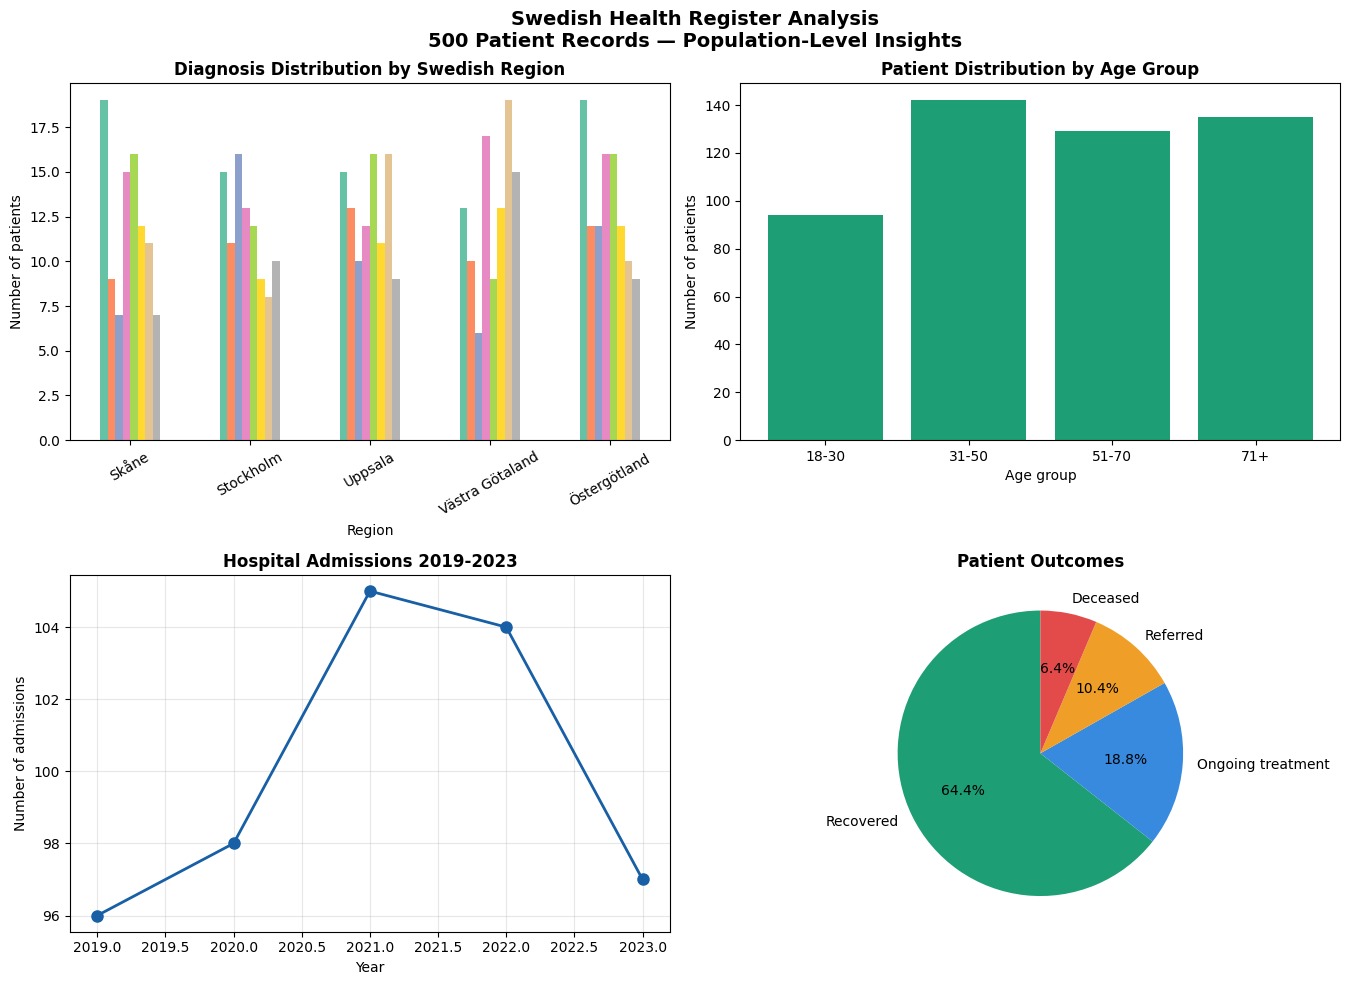

Visualisations saved!


In [3]:
# Step 2 — Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Swedish Health Register Analysis\n500 Patient Records — Population-Level Insights', 
             fontsize=14, fontweight='bold')

# Plot 1 — Diagnoses by region
region_diag = df.groupby(['region', 'diagnosis_name']).size().unstack(fill_value=0)
region_diag.plot(kind='bar', ax=axes[0,0], colormap='Set2', legend=False)
axes[0,0].set_title('Diagnosis Distribution by Swedish Region', fontweight='bold')
axes[0,0].set_xlabel('Region')
axes[0,0].set_ylabel('Number of patients')
axes[0,0].tick_params(axis='x', rotation=30)

# Plot 2 — Age group distribution
age_counts = df['age_group'].value_counts().sort_index()
axes[0,1].bar(age_counts.index, age_counts.values, color='#1D9E75')
axes[0,1].set_title('Patient Distribution by Age Group', fontweight='bold')
axes[0,1].set_xlabel('Age group')
axes[0,1].set_ylabel('Number of patients')

# Plot 3 — Hospital admissions over years
year_counts = df['admission_year'].value_counts().sort_index()
axes[1,0].plot(year_counts.index, year_counts.values, 
               marker='o', color='#185FA5', linewidth=2, markersize=8)
axes[1,0].set_title('Hospital Admissions 2019-2023', fontweight='bold')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Number of admissions')
axes[1,0].grid(True, alpha=0.3)

# Plot 4 — Treatment outcomes
outcome_counts = df['outcome'].value_counts()
colors = ['#1D9E75', '#378ADD', '#EF9F27', '#E24B4A']
axes[1,1].pie(outcome_counts.values, labels=outcome_counts.index, 
              colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Patient Outcomes', fontweight='bold')

plt.tight_layout()
plt.savefig('health_register_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisations saved!")

In [4]:
# Step 3 — Population Health Summary
print("=" * 50)
print("   SWEDISH HEALTH REGISTER — SUMMARY REPORT")
print("=" * 50)

print(f"\nTotal patients: {len(df)}")
print(f"Age range: {df['age'].min()} — {df['age'].max()} years")
print(f"Mean age: {df['age'].mean():.1f} years")

print(f"\nSex distribution:")
print(df['sex'].value_counts().to_string())

print(f"\nAverage length of stay by diagnosis:")
stay = df.groupby('diagnosis_name')['length_of_stay'].mean().sort_values(ascending=False)
for diag, days in stay.items():
    print(f"  {diag:<35} {days:.1f} days")

print(f"\nRecovery rate by age group:")
for age_grp in ['18-30', '31-50', '51-70', '71+']:
    group = df[df['age_group'] == age_grp]
    recovery = (group['outcome'] == 'Recovered').sum() / len(group) * 100
    print(f"  {age_grp}: {recovery:.1f}%")

print(f"\nMost affected region: {df['region'].value_counts().index[0]}")
print(f"Most common diagnosis: {df['diagnosis_name'].value_counts().index[0]}")
print("\nData ready for longitudinal register linkage.")
print("=" * 50)

   SWEDISH HEALTH REGISTER — SUMMARY REPORT

Total patients: 500
Age range: 18 — 89 years
Mean age: 53.6 years

Sex distribution:
sex
Female    266
Male      234

Average length of stay by diagnosis:
  Lung Cancer                         16.5 days
  Acute Myocardial Infarction         16.4 days
  Type 2 Diabetes                     16.3 days
  COPD                                15.7 days
  Depression                          15.4 days
  Back Pain                           15.2 days
  Pneumonia                           15.1 days
  Hypertension                        14.0 days

Recovery rate by age group:
  18-30: 57.4%
  31-50: 67.6%
  51-70: 62.8%
  71+: 67.4%

Most affected region: Östergötland
Most common diagnosis: Acute Myocardial Infarction

Data ready for longitudinal register linkage.
